# Physics Informed Neural Network (PINN) for Advection-diffusion Model

This notebook aims to generate synthetic data for training an inverse PINN for the an advection difussion problem with varying transport properties.

$$
\beta \frac{\partial u}{\partial t} + \nabla \cdot (V(x) u - D(x) \nabla u) = \sigma (u),
$$ 


where $\beta$ is the porosity term, $V(x)$ is the Darcy velocity, $D(x)$ is the dispersion/diffusion, notice both functions are spacial-dependent . $\sigma (u)$ can be a non-linear function of the concentration. 

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

In [104]:
# Domain parameters
x_min, x_max = 0, 1
t_min, t_max = 0, 0.1

# Spatial and temporal discretization
nx = 100  # Number of spatial points (higher for accurate simulation)
nt = 200  # Number of temporal points
x = np.linspace(x_min, x_max, nx)
t = np.linspace(t_min, t_max, nt)
dx = x[1] - x[0]
dt = t[1] - t[0]

# Physical parameters
beta = 1.0  # Porosity (constant)

# Create solution array
c = np.zeros((nx, nt))

In [105]:
def u_true(x, zero = None):
    """
    True advection velocity u(x)
    Can be modified to test different profiles
    """
    if not zero:
        # Sinusoidal variation
        u = 0.5 + 0.3 * np.sin(2 * np.pi * x)
        u = u / np.max(u)  # Normalize to max value of 1

    else:
        u = np.zeros(x.shape[0])  # Set specified points to zero velocity
    return u

def D_true(x, constant = None):
    """
    True diffusion coefficient D(x)
    """
    if constant is not None:
        d = np.full(x.shape[0], constant)
    else:
        # Parabolic variation
        d = 0.05 + 0.1 * x * (1 - x)
        d = d / np.max(d)  # Normalize to max value of 1
    return d

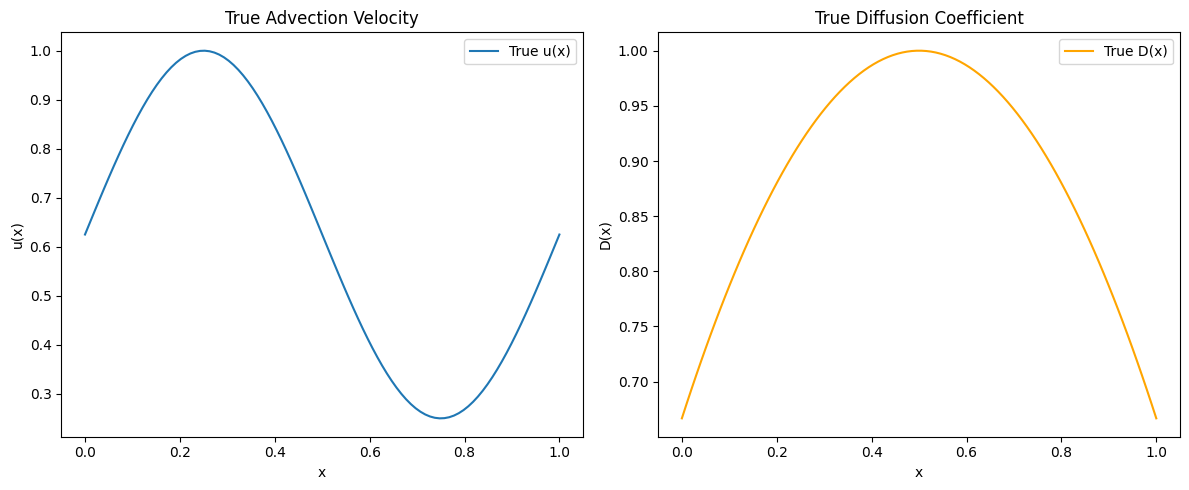

In [127]:
# Plot true profiles
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x, u_true(x), label='True u(x)')
plt.title('True Advection Velocity')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(x, D_true(x), label='True D(x)', color='orange')
plt.title('True Diffusion Coefficient')
plt.xlabel('x')
plt.ylabel('D(x)')
plt.legend()
plt.tight_layout()
plt.show()

In [107]:
def initial_condition(x, type="sin"):
    """
    Initial condition c(x, 0)
    """
    if type == "sin":
        # Sinusoidal initial condition
        c = np.sin(np.pi * x)
    elif type == "gaussian":
        # Gaussian normalized pulse
        c = np.exp(-((x - 0.5) ** 2) / 0.01)
        c = c / np.max(c)  # Normalize to max value of 1
    elif type == "logaritmic":
        # Logarithmic initial condition
        c = np.log(1 + 9 * x)
        # c = c / np.max(c)  # Normalize to max value of 1
    else:
        c = np.ones(x.shape[0])  # Default to one initial condition

    return c

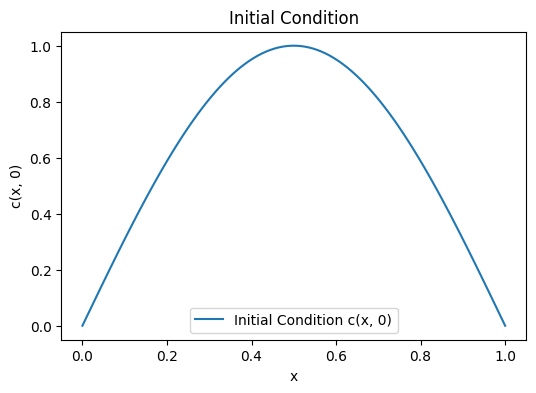

In [108]:
# Plot initial condition
plt.figure(figsize=(6, 4))
plt.plot(x, initial_condition(x, type="sin"), label='Initial Condition c(x, 0)')
plt.title('Initial Condition')
plt.xlabel('x')
plt.ylabel('c(x, 0)')
plt.legend()
plt.show()

In [109]:
def setup_matrices(u, d, nx, dx, dt, beta0):
    """
    Set up the coefficient matrices for the implicit finite difference scheme
    Returns:
        A: Coefficient matrix for c^{n+1}
        B: Coefficient matrix for c^n
    """
    d_factor = (d * dt) / (beta0 * dx**2)
    r_factor = (dt) / (beta0 * dx) 
    
    d_j = d_factor[1:-1]
    d_j_plus = d_factor[2:]

    u_j = u[1:-1]
    u_j_plus = u[2:]

    # Diagonals
    main_diag_A = -r_factor * u_j + d_j + d_j_plus + 2 * np.ones(nx - 2)
    main_diag_B = r_factor * u_j - d_j - d_j_plus + 2 * np.ones(nx - 2)

    # Off-diagonals

    # Lower diagonal
    lower_diag_A = - d_j
    lower_diag_B = d_j

    # Upper diagonal
    upper_diag_A = r_factor * u_j_plus - d_j_plus
    upper_diag_B = - r_factor * u_j_plus + d_j_plus

    # Create sparse matrices
    A_matrix = diags([lower_diag_A, main_diag_A, upper_diag_A], [-1, 0, 1], shape=(nx-2, nx-2), format='csc')
    B_matrix = diags([lower_diag_B, main_diag_B, upper_diag_B], [-1, 0, 1], shape=(nx-2, nx-2), format='csc')

    return d_factor, r_factor, A_matrix, B_matrix

In [128]:
def solve_CrankNicolson(c, u, D, nx, dx, dt, beta0):
    """
    Solve the system using the Cranck-Nicolson method
    """

    d, r, A, B = setup_matrices(u, D, nx, dx, dt, beta0)

    for n in range(0, nt - 1):

        # Initial conditions to the initial b vector
        b = c[1:-1, n].copy()

        # Evaluate the RHS
        b = B.dot(b)

        # Append missing values 
        b[0] += d[1] * (c[0, n] + c[0, n + 1])
        b[-1] += (-r * u[-1] + d[-1]) * (c[-1, n] + c[-1, n +1])

        # Compute the solution vector
        sln_b = spsolve(A, b)

        # Update the solution for the next time step
        c[1:-1, n + 1] = sln_b   
    
    return c

## Create a python class that make easier run the simulation

In [84]:
class CrankNicolsonSolver:
    def __init__(self, x_min=0, x_max=1, nx=100, t_min=0, t_max=1, nt=100, 
                 beta0=1.0, D_type="Constant", u_type="zero", type_ic="sin"):

        # Simulation parameters
        self.xmin = x_min
        self.xmax = x_max
        self.nx = nx
        self.tmin = t_min
        self.tmax = t_max
        self.nt = nt
        self.beta0 = beta0

        # Spatial and temporal discretization
        self.x = np.linspace(self.xmin, self.xmax, self.nx)
        self.t = np.linspace(self.tmin, self.tmax, self.nt)
        self.dx = self.x[1] - self.x[0]
        self.dt = self.t[1] - self.t[0]

        # Set velocity and diffusion profiles
        self.set_u(self.x, u_type=u_type)
        self.set_D(self.x, d_type=D_type)

        # Setup matrices
        self.setup_matrices()

        # Create solution array
        self.c = np.zeros((self.nx, self.nt))

        # Set initial condition
        self.set_initial_conditions(type=type_ic)
    
    def set_u(self, x, u_type = "zero"):
        """
        True advection velocity u(x)
        Can be modified to test different profiles
        """
        if u_type == "zero":
            self.u_arr = np.zeros(x.shape[0])  # Set specified points to zero velocity
        elif u_type == "sin":
            # Sinusoidal variation
            u = 0.5 + 0.3 * np.sin(2 * np.pi * x)
            self.u_arr = u / np.max(u)  # Normalize to max value of 1
        elif u_type == "linear":
            # Linear variation
            u = 0.5 + 0.3 * x
            self.u_arr = u / np.max(u)  # Normalize to max value of 1
        elif u_type == "linear_inv":
            # Linear inverse variation
            u = 0.5 + 0.3 * (1 - x)
            self.u_arr = u / np.max(u)  # Normalize to max value of 1
        elif u_type == "constant":
            self.u_arr = np.full(x.shape[0], 0.5)  # Constant velocity
        else:
            print("Invalid u_type specified. Choose between 'zero', 'sin', and 'linear'")

    def set_D(self, x, d_type = "constant"):
        """
        True diffusion coefficient D(x)
        """
        if d_type == "constant":
            self.D_arr = np.full(x.shape[0], 1.0)
        elif d_type == "parabolic":
            # Parabolic variation
            d = 0.05 + 0.1 * x * (1 - x)
            self.D_arr = d / np.max(d)  # Normalize to max value of 1
        elif d_type == "linear":    
            d = 0.05 + 0.1 * x
            self.D_arr = d / np.max(d)  # Normalize to max value of 1
        elif d_type == "linear_inv":
            d = 0.05 + 0.1 * (1 - x)
            self.D_arr = d / np.max(d)  # Normalize to max value of 1
        else:
            print("Invalid d_type specified. Choose between 'constant', 'parabolic', 'linear', and 'linear_inv'")

    def set_initial_conditions(self, type="sin"):
        """
        Set the initial condition for the concentration field
        """
        if type == "sin":
            # Sinusoidal initial condition
            self.c[:, 0] = np.sin(np.pi * self.x)

        elif type == "gaussian":
            # Gaussian normalized pulse
            c = np.exp(-((self.x - 0.5) ** 2) / 0.01)
            self.c[:, 0] = c / np.max(c)  # Normalize to max value of 1

        else:
            self.c[:, 0] = np.ones(self.x.shape[0])  # Default to one initial condition

    def setup_matrices(self):
        """
        Set up the coefficient matrices for the implicit finite difference scheme
        Returns:
            A: Coefficient matrix for c^{n+1}
            B: Coefficient matrix for c^n
        """
        self.d_factor = (self.D_arr * self.dt) / (self.beta0 * self.dx**2)
        self.r_factor = (self.dt) / (self.beta0 * self.dx) 
        
        d_j = self.d_factor[1:-1]
        d_j_plus = self.d_factor[2:]

        u_j = self.u_arr[1:-1]
        u_j_plus = self.u_arr[2:]

        # Diagonals
        main_diag_A = -self.r_factor * u_j + d_j + d_j_plus + 2 * np.ones(self.nx - 2)
        main_diag_B = self.r_factor * u_j - d_j - d_j_plus + 2 * np.ones(self.nx - 2)

        # Off-diagonals

        # Lower diagonal
        lower_diag_A = - d_j
        lower_diag_B = d_j

        # Upper diagonal
        upper_diag_A = self.r_factor * u_j_plus - d_j_plus
        upper_diag_B = - self.r_factor * u_j_plus + d_j_plus

        # Create sparse matrices
        self.A_matrix = diags([lower_diag_A, main_diag_A, upper_diag_A], [-1, 0, 1], shape=(self.nx-2, self.nx-2), format='csc')
        self.B_matrix = diags([lower_diag_B, main_diag_B, upper_diag_B], [-1, 0, 1], shape=(self.nx-2, self.nx-2), format='csc')

    def solve(self):
        for n in range(0, self.nt - 1):

            # Initial conditions to the initial b vector
            b = self.c[1:-1, n].copy()

            # Evaluate the RHS
            b = self.B_matrix.dot(b)

            # Append missing values 
            b[0] += self.d_factor[1] * (self.c[0, n] + self.c[0, n + 1])
            b[-1] += (-self.r_factor * self.u_arr[-1] + self.d_factor[-1]) * (self.c[-1, n] + self.c[-1, n +1])

            # Compute the solution vector
            sln_b = spsolve(self.A_matrix, b)

            # Update the solution for the next time step
            self.c[1:-1, n + 1] = sln_b
        
        return self.D_arr, self.u_arr, self.t, self.x, self.c

In [86]:
class CrankNicolsonSolverNBCs:
    def __init__(self, x_min=0, x_max=1, nx=100, t_min=0, t_max=1, nt=100, 
                 beta0=1.0, D_type="Constant", u_type="zero", type_ic="sin"):

        # Simulation parameters
        self.xmin = x_min
        self.xmax = x_max
        self.nx = nx
        self.tmin = t_min
        self.tmax = t_max
        self.nt = nt
        self.beta0 = beta0

        # Spatial and temporal discretization
        self.x = np.linspace(self.xmin, self.xmax, self.nx)
        self.t = np.linspace(self.tmin, self.tmax, self.nt)
        self.dx = self.x[1] - self.x[0]
        self.dt = self.t[1] - self.t[0]

        # Set velocity and diffusion profiles
        self.set_u(self.x, u_type=u_type)
        self.set_D(self.x, d_type=D_type)

        # Setup matrices
        self.setup_matrices()

        # Create solution array
        self.c = np.zeros((self.nx, self.nt))

        # Set initial condition
        self.set_initial_conditions(type=type_ic)
    
    def set_u(self, x, u_type = "zero"):
        """
        True advection velocity u(x)
        Can be modified to test different profiles
        """
        if u_type == "zero":
            self.u_arr = np.zeros(x.shape[0])  # Set specified points to zero velocity
        elif u_type == "sin":
            # Sinusoidal variation
            u = 0.5 + 0.3 * np.sin(2 * np.pi * x)
            self.u_arr = u / np.max(u)  # Normalize to max value of 1
        elif u_type == "linear":
            # Linear variation
            u = 0.5 + 0.3 * x
            self.u_arr = u / np.max(u)  # Normalize to max value of 1
        elif u_type == "linear_inv":
            # Linear inverse variation
            u = 0.5 + 0.3 * (1 - x)
            self.u_arr = u / np.max(u)  # Normalize to max value of 1
        elif u_type == "constant":
            self.u_arr = np.full(x.shape[0], 0.5)  # Constant velocity
        else:
            print("Invalid u_type specified. Choose between 'zero', 'sin', 'linear', 'linear_inv', and 'constant'")

    def set_D(self, x, d_type = "constant"):
        """
        True diffusion coefficient D(x)
        """
        if d_type == "constant":
            self.D_arr = np.full(x.shape[0], 1.0)
        elif d_type == "parabolic":
            # Parabolic variation
            d = 0.05 + 0.1 * x * (1 - x)
            self.D_arr = d / np.max(d)  # Normalize to max value of 1
        elif d_type == "linear":    
            d = 0.05 + 0.1 * x
            self.D_arr = d / np.max(d)  # Normalize to max value of 1
        elif d_type == "linear_inv":
            d = 0.05 + 0.1 * (1 - x)
            self.D_arr = d / np.max(d)  # Normalize to max value of 1
        else:
            print("Invalid d_type specified. Choose between 'constant', 'parabolic', 'linear', and 'linear_inv'")

    def set_initial_conditions(self, type="sin"):
        """
        Set the initial condition for the concentration field
        """
        if type == "sin":
            # Sinusoidal initial condition
            self.c[:, 0] = np.sin(np.pi * self.x)

        elif type == "gaussian":
            # Gaussian normalized pulse
            c = np.exp(-((self.x - 0.5) ** 2) / 0.01)
            self.c[:, 0] = c / np.max(c)  # Normalize to max value of 1

        else:
            self.c[:, 0] = np.ones(self.x.shape[0])  # Default to one initial condition

    def setup_matrices(self):
        self.d_factor = (self.D_arr * self.dt) / (self.beta0 * self.dx**2)
        self.r_factor = self.dt / (self.beta0 * self.dx)

        d = self.d_factor
        u = self.u_arr
        r = self.r_factor
        n = self.nx

        # Off-diagonals: same formula as interior, for all n-1 faces
        # lower[k] → row k+1, col k;  upper[k] → row k, col k+1
        lower_A = -d[1:]                  # -d[i]        for rows 1..n-1
        upper_A =  r * u[1:] - d[1:]     # r*u[i+1]-d[i+1] for rows 0..n-2
        lower_B =  d[1:]
        upper_B = -r * u[1:] + d[1:]

        # Main diagonal: left BC has no d[0]/u[0] (J[0]=0), right BC has no d[n]/u[n] (J[nx]=0)
        d_left  = np.concatenate([[0.0],  d[1:]])    # 0 at node 0, d[i]   for i>=1
        d_right = np.concatenate([d[1:],  [0.0]])    # d[i+1] for i<n-1, 0 at node n-1
        u_left  = np.concatenate([[0.0],  u[1:]])    # 0 at node 0, u[i]   for i>=1

        main_A = 2 + d_left + d_right - r * u_left
        main_B = 2 - d_left - d_right + r * u_left

        self.A_matrix = diags([lower_A, main_A, upper_A], [-1, 0, 1], shape=(n, n), format='csc')
        self.B_matrix = diags([lower_B, main_B, upper_B], [-1, 0, 1], shape=(n, n), format='csc')

    def solve(self):
        for n in range(0, self.nt - 1):
            b = self.B_matrix.dot(self.c[:, n])   # full nx vector
            self.c[:, n + 1] = spsolve(self.A_matrix, b)
        return self.D_arr, self.u_arr, self.t, self.x, self.c

In [127]:
def save_data(D, u, t, x, c, filename="data/advection_diffusion_v_u_varying"):
    """
    Save the generated data to .csv files
    """
    # Create the directory if it doesn't exist
    import os
    # Check if the directory exists, if not, create it
    if not os.path.exists(filename):
        os.makedirs(filename)
        print(f"Directory '{filename}' created.")
    else:
        print(f"Directory '{filename}' already exists.")

    D_df = pd.DataFrame(D)
    u_df = pd.DataFrame(u)
    t_df = pd.DataFrame(t)
    x_df = pd.DataFrame(x)
    c = c.T.flatten()
    c_df = pd.DataFrame(c)

    D_df.to_csv(f"{filename}/D.csv", index=False, header=False)
    u_df.to_csv(f"{filename}/u.csv", index=False, header=False)
    t_df.to_csv(f"{filename}/t.csv", index=False, header=False)
    x_df.to_csv(f"{filename}/x.csv", index=False, header=False)
    c_df.to_csv(f"{filename}/c.csv", index=False, header=False)

    print(f"Data saved successfully to {filename}/")

## Check the code: Create a solution for the simplest case (simple constant diffusion)

In [94]:
# Instantiate the class
solver_test1 = CrankNicolsonSolver(x_min=0, x_max=1, nx=100, t_min=0, t_max=0.1, nt=200, 
                              beta0=1.0, D_type="constant", u_type="zero", type_ic="sin")

solver_test1_NBCs = CrankNicolsonSolverNBCs(x_min=0, x_max=1, nx=100, t_min=0, t_max=0.1, nt=200,
                                beta0=1.0, D_type="constant", u_type="zero", type_ic="sin")

In [98]:
D_test1, u_test1, t_test1, x_test1, c_test1 = solver_test1.solve()

In [99]:
_, _, _, _, c_test1_NBCs = solver_test1_NBCs.solve()

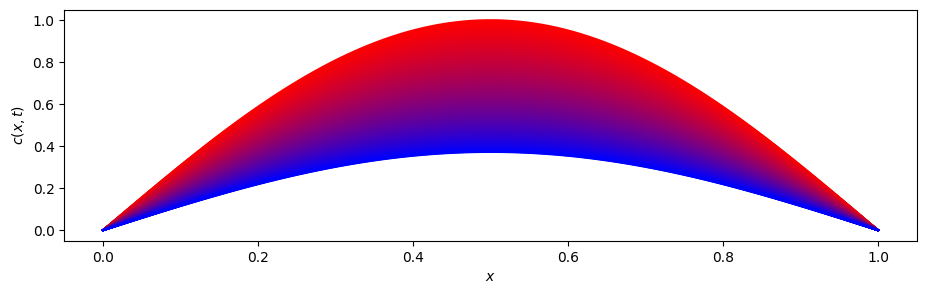

In [100]:
# Plotting
R = np.linspace(1, 0, solver_test1.nt)
G = 0
B = np.linspace(0, 1, solver_test1.nt)

# FIgure environment
plt.figure(figsize=(11,3))

for j in range(solver_test1.nt):
    plt.plot(x_test1, c_test1[:, j] , color = [R[j], G, B[j]])

plt.xlabel(r"$x$")
plt.ylabel(r"$c(x,t)$")
plt.show()

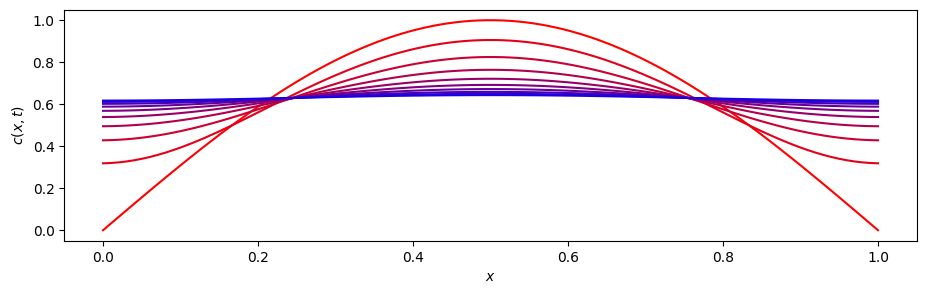

In [102]:
# Plotting
R = np.linspace(1, 0, solver_test1.nt)
G = 0
B = np.linspace(0, 1, solver_test1.nt)

# FIgure environment
plt.figure(figsize=(11,3))

for j in range(0, solver_test1.nt, solver_test1.nt // 10):
    plt.plot(x_test1, c_test1_NBCs[:, j] , color = [R[j], G, B[j]])

plt.xlabel(r"$x$")
plt.ylabel(r"$c(x,t)$")
plt.show()

## Solution for sinusoidal velocity advection and parabolic diffusion

In [111]:
# Porosity parameter
beta0 = 1.0

# Instantiate the class
solver_test2 = CrankNicolsonSolver(x_min=0, x_max=1, nx=100, t_min=0, t_max=0.1, nt=100, 
                              beta0=beta0, D_type="linear", u_type="constant", type_ic="sin")
solver_test2_NBCs = CrankNicolsonSolverNBCs(x_min=0, x_max=1, nx=100, t_min=0, t_max=0.1, nt=100,
                                beta0=beta0, D_type="linear", u_type="constant", type_ic="sin")

In [112]:
D_test2, u_test2, t_test2, x_test2, c_test2 = solver_test2.solve()

In [113]:
_, _, t_test2_NBCs, x_test2_NCs, c_test2_NBCs = solver_test2_NBCs.solve()

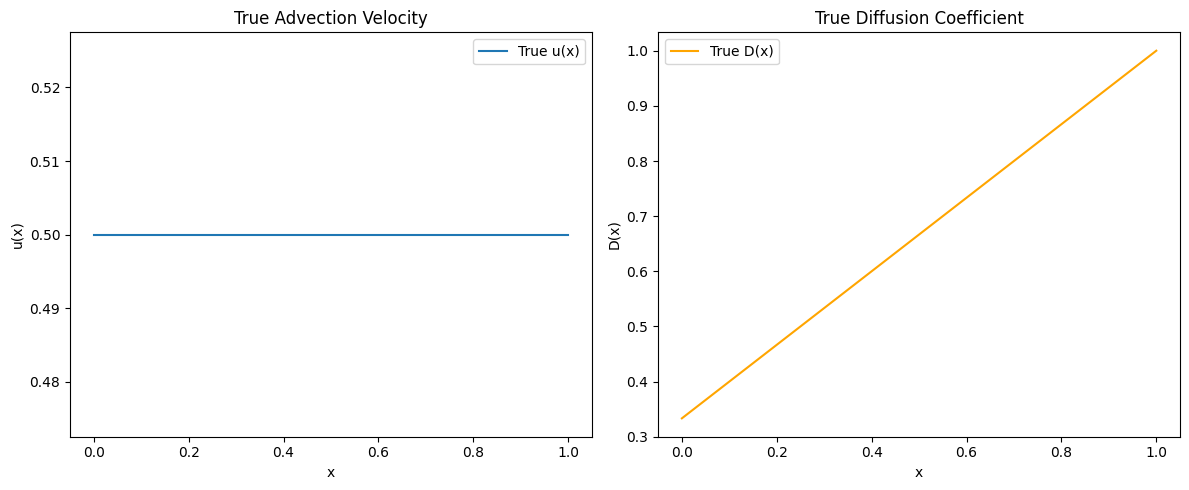

In [114]:
# Plot true profiles
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x_test2, u_test2, label='True u(x)')
plt.title('True Advection Velocity')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(x_test2, D_test2, label='True D(x)', color='orange')
plt.title('True Diffusion Coefficient')
plt.xlabel('x')
plt.ylabel('D(x)')
plt.legend()
plt.tight_layout()
plt.show()

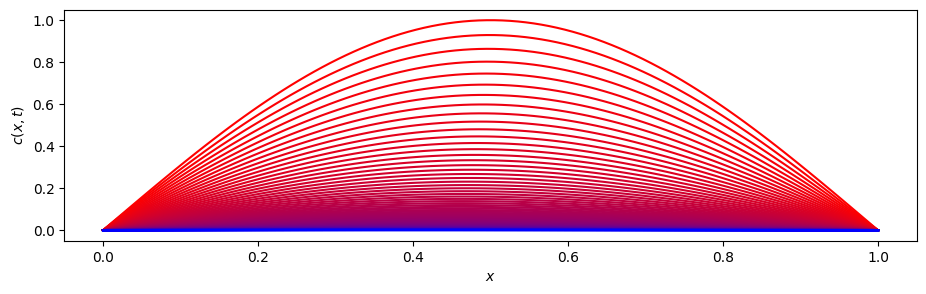

In [115]:
# Figure environment
# Plotting
R = np.linspace(1, 0, solver_test2.nt)
G = 0
B = np.linspace(0, 1, solver_test2.nt)

plt.figure(figsize=(11,3))

for j in range(solver_test2.nt):
    plt.plot(x_test2, c_test2[:, j] , color = [R[j], G, B[j]])

plt.xlabel(r"$x$")
plt.ylabel(r"$c(x,t)$")
plt.show()

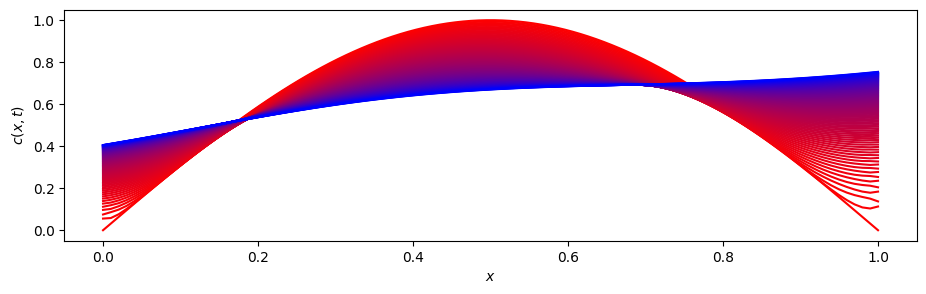

In [118]:
# Figure environment
# Plotting
R = np.linspace(1, 0, solver_test2.nt)
G = 0
B = np.linspace(0, 1, solver_test2.nt)

plt.figure(figsize=(11,3))

for j in range(solver_test2.nt):
    plt.plot(x_test2, c_test2_NBCs[:, j] , color = [R[j], G, B[j]])

plt.xlabel(r"$x$")
plt.ylabel(r"$c(x,t)$")
# plt.ylim(0, 4.)
plt.show()

Check the flux conservation:

In [119]:
# Total mass should be ~constant over time
mass = np.trapz(solver_test2_NBCs.c, solver_test2_NBCs.x, axis=0)
print(mass.max() - mass.min())  # should be near 0

0.005856117927531823


In [120]:
# Duplicate u and d to match the shape of c for flux calculations
u_test2_2D = np.tile(u_test2, (solver_test2.nt, 1)).T
D_test2_2D = np.tile(D_test2, (solver_test2.nt, 1)).T

In [121]:
# Total mass should be ~constant over time
f = u_test2_2D * c_test2_NBCs  - D_test2_2D * np.gradient(c_test2_NBCs, x_test2, axis=0)  # Flux at each point 

In [122]:
print(f.mean())  # should be near 0

0.2635420412424552


In [128]:
# Save the data
save_data(D_test2, u_test2, t_test2, x_test2, c_test2_NBCs, filename="data/advection_diffusion_varying_profiles")

Directory 'data/advection_diffusion_varying_profiles' already exists.
Data saved successfully to data/advection_diffusion_varying_profiles/


In [124]:
param = np.zeros(5)
param[0] = beta0

pd.DataFrame(param).to_csv("data/advection_diffusion_varying_profiles/p.csv", index=False, header=False)